### Importing Required Libraries

This step imports all the essential Python libraries needed for the machine-learning workflow. These include tools for data manipulation, preprocessing, model training, and model evaluation, which will be used throughout the analysis.

In [164]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

### Loading the Dataset and Inspecting Its Structure

In this step, we load the synthetic resume dataset using `pandas.read_csv()` and display the basic structure of the data.  
We print the dataset’s shape to see the number of rows and columns, and list all column names to understand the available features before

In [167]:
df = pd.read_csv("data/resume_raw_data.csv")

print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())



Original shape: (1900, 32)
Columns: ['Candidate_ID', 'Resume_title', 'Resume_title_relation_to_JD', 'Education', 'Field_of_study', 'Years_of_experience', 'Previous_job_titles', 'Skills', 'Certifications', 'Projects', 'Location', 'Expected_salary', 'Job_ID', 'Job_title', 'Category', 'Required_skills', 'Required_experience', 'Salary_range_NPR', 'Summary', 'Responsibilities', 'Preferred_qualifications', 'Education_requirement', 'Employment_type', 'Primary_location', 'Title_variations_for_bias_testing', 'Notes', 'Technical_score', 'Experience_score', 'Education_score', 'Softskills_score', 'Overall_score', 'Selection_recommendation']


### Loading the Dataset and Inspecting Its Structure

In this step, we load the synthetic resume dataset using `pandas.read_csv()` and display the basic structure of the data.  
We print the dataset’s shape to see the number of rows and columns, and list all column names to understand the available features before

### Exploring Dataset Structure and Summary Statistics

This step provides an initial overview of the dataset.  
- `df.info()` shows the data types, column counts, and presence of missing values.  
- `df.describe(include='all')` generates summary statistics for both numerical and categorical features.  

These summaries help assess data quality and guide decisions for preprocessing and feature engineering.

In [171]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Candidate_ID                       1900 non-null   object 
 1   Resume_title                       1900 non-null   object 
 2   Resume_title_relation_to_JD        1900 non-null   object 
 3   Education                          1900 non-null   object 
 4   Field_of_study                     1900 non-null   object 
 5   Years_of_experience                1900 non-null   int64  
 6   Previous_job_titles                1900 non-null   object 
 7   Skills                             1900 non-null   object 
 8   Certifications                     1900 non-null   object 
 9   Projects                           1900 non-null   object 
 10  Location                           1900 non-null   object 
 11  Expected_salary                    1900 non-null   int64

,Candidate_ID,Resume_title,Resume_title_relation_to_JD,Education,Field_of_study,Years_of_experience,Previous_job_titles,Skills,Certifications,Projects,Location,Expected_salary,Job_ID,Job_title,Category,Required_skills,Required_experience,Salary_range_NPR,Summary,Responsibilities,Preferred_qualifications,Education_requirement,Employment_type,Primary_location,Title_variations_for_bias_testing,Notes,Technical_score,Experience_score,Education_score,Softskills_score,Overall_score,Selection_recommendation
count,1900,1900,1900,1900,1900,1900.000000,1900,1900,1900,1900,1900,1900.000000,1900,1900,1900,1900,1900,1900,1900,1900,1900,1900,1900,1900,1900,1900,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900
unique,1900,76,3,3,7,NaN,170,365,240,1437,10,NaN,19,19,6,19,4,6,19,1,1,1,1,1,19,1,NaN,NaN,NaN,NaN,NaN,4
top,SE-JD1-01,UI Developer,exact_or_related,Bachelor's,Computer Engineering,NaN,Infrastructure Engineer; Platform Engineer,Java; Spring; SQL; Git; Docker; REST,Scrum Fundamentals; Jenkins (course),Service Git; Engine Git,Pokhara,NaN,SE-JD1,Software Engineer,Software/Backend,Java; Spring; SQL; Git; Docker; REST,1-3 years,60000-120000,Hire a Software Engineer in Nepal market to deliver production features aligned to business goals.,"Design, build, and maintain production-grade features; Collaborate with cross-functional teams (PM, QA, DevOps); Write clean, testable, and documented code; Participate in code reviews and sprint ceremonies; Monitor, troubleshoot, and improve performance",Experience with cloud platforms (AWS/Azure/GCP); CI/CD exposure (GitHub Actions/Jenkins); Knowledge of security and best practices; Familiarity with Agile/Scrum,Bachelor's in CS/CE/IT or related; Master's preferred for senior roles,Full-time,Nepal (Kathmandu preferred),Software Developer; Backend Engineer; Programmer; Associate Software Engineer; Java Developer,Includes broad score spread and title relations for bias experiments,NaN,NaN,NaN,NaN,NaN,Shortlist
freq,1,76,1185,1421,284,NaN,26,48,18,6,214,NaN,100,100,600,100,500,600,100,1900,1900,1900,1900,1900,100,1900,NaN,NaN,NaN,NaN,NaN,1052
mean,NaN,NaN,NaN,NaN,NaN,4.818947,NaN,NaN,NaN,NaN,NaN,84235.789474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72.598421,65.235789,79.444211,74.021053,72.001421,NaN
std,NaN,NaN,NaN,NaN,NaN,2.603287,NaN,NaN,NaN,NaN,NaN,21681.236641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.715621,11.011468,5.029093,8.460831,8.055754,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,44000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,44.000000,66.000000,60.000000,50.800000,NaN
25%,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,68000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.000000,57.000000,78.000000,67.000000,66.200000,NaN
50%,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,81000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.000000,64.000000,78.000000,74.000000,72.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,97000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.000000,73.000000,78.000000,82.000000,77.600000,NaN


### Checking for Missing Values

This step calculates the number of missing values in each column and sorts them in descending order.  
It helps identify which features may require cleaning, imputation, or removal before building the machine-learning model.

In [174]:
df.isnull().sum().sort_values(ascending=False)

Candidate_ID                         0
Resume_title                         0
Overall_score                        0
Softskills_score                     0
Education_score                      0
Experience_score                     0
Technical_score                      0
Notes                                0
Title_variations_for_bias_testing    0
Primary_location                     0
Employment_type                      0
Education_requirement                0
Preferred_qualifications             0
Responsibilities                     0
Summary                              0
Salary_range_NPR                     0
Required_experience                  0
Required_skills                      0
Category                             0
Job_title                            0
Job_ID                               0
Expected_salary                      0
Location                             0
Projects                             0
Certifications                       0
Skills                   

### Checking for Duplicate Records

This step identifies how many duplicate rows exist in the dataset.  
Detecting duplicates helps ensure data quality, as duplicated records can bias model training and distort results.

In [177]:
df.duplicated().sum()


0

### Inspecting the Most Common Resume Titles

This step displays the top 10 most frequent resume titles in the dataset.  
Understanding title distribution helps assess class balance and provides insight into how job titles vary across candidates—an important factor for the bias analysis.

In [180]:
df['Resume_title'].value_counts().head(10)

Resume_title
UI Developer                       76
Software Tester                    66
Data Scientist                     63
Backend Engineer                   59
Automation Engineer                58
Site Reliability Engineer (SRE)    56
Server-Side Developer              56
QA Engineer                        55
Data Analyst                       53
Frontend Engineer                  53
Name: count, dtype: int64

### Visualizing the Distribution of Overall Scores

This step plots a histogram of the `Overall_score` column to examine how the target variable is distributed.  
Understanding the score distribution helps identify skewness, potential outliers, and whether scaling or transformation may be necessary before model training.


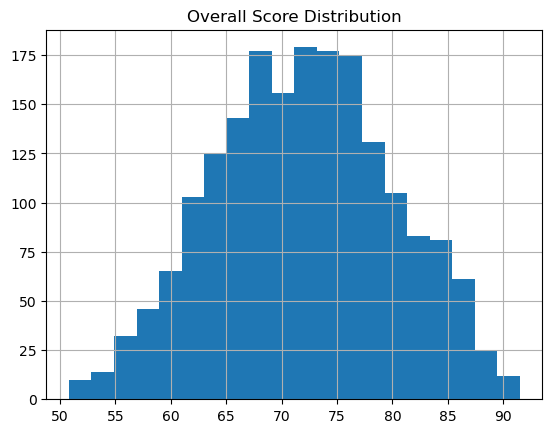

In [183]:
import matplotlib.pyplot as plt

df['Overall_score'].hist(bins=20)
plt.title("Overall Score Distribution")
plt.show()

### Check class balance or distribution for key categorical features

In [186]:
df['Education'].value_counts()
df['Field_of_study'].value_counts()

Field_of_study
Computer Engineering             284
Software Engineering             277
Computer Science                 275
Information Technology           274
Information Systems              266
Computer Applications            264
Electronics and Communication    260
Name: count, dtype: int64

In [188]:
df.corr(numeric_only=True)

,Years_of_experience,Expected_salary,Technical_score,Experience_score,Education_score,Softskills_score,Overall_score
Years_of_experience,1.000000,0.592476,0.392653,0.941535,0.562175,-0.014674,0.673021
Expected_salary,0.592476,1.000000,0.200459,0.550415,0.320548,0.013557,0.373881
Technical_score,0.392653,0.200459,1.000000,0.359865,0.287462,0.000313,0.915792
Experience_score,0.941535,0.550415,0.359865,1.000000,0.537883,-0.011013,0.666210
Education_score,0.562175,0.320548,0.287462,0.537883,1.000000,-0.000393,0.497854
Softskills_score,-0.014674,0.013557,0.000313,-0.011013,-0.000393,1.000000,0.153883
Overall_score,0.673021,0.373881,0.915792,0.666210,0.497854,0.153883,1.000000


In [190]:
(df['Resume_title'].value_counts() / len(df)) * 100

Resume_title
UI Developer                       4.000000
Software Tester                    3.473684
Data Scientist                     3.315789
Backend Engineer                   3.105263
Automation Engineer                3.052632
Site Reliability Engineer (SRE)    2.947368
Server-Side Developer              2.947368
QA Engineer                        2.894737
Data Analyst                       2.789474
Frontend Engineer                  2.789474
Application Developer              2.789474
Web Developer                      2.736842
Business Intelligence Analyst      2.578947
DevOps Engineer                    2.421053
Full Stack Developer               2.315789
React Developer                    2.263158
Software Engineer                  2.210526
Cloud Engineer                     2.052632
API Developer                      1.947368
Platform Engineer                  1.894737
QA Tester                          1.789474
Backend Developer                  1.789474
UI Engineer        

### Selecting Resume-Specific Features for Modeling

In this step, we create a focused modeling dataset by selecting only the resume-side attributes that describe each candidate. These features represent the candidate’s qualifications, skills, and self-reported title—without including job description or employer-side information.

We also specify `Overall_score` as the target variable for prediction.  
The resulting dataset (`df_model`) includes only the relevant input features and the target needed for machine-learning model training.


In [193]:
resume_features = [
    "Resume_title",
    "Education",
    "Field_of_study",
    "Years_of_experience",
    "Previous_job_titles",
    "Skills",
    "Certifications",
    "Projects",
    "Expected_salary",
    "Technical_score",
    "Experience_score",
    "Education_score",
    "Softskills_score",
]

target = "Overall_score"

df_model = df[resume_features + [target]].copy()
print("Modeling dataset shape:", df_model.shape)
print("Modeling columns:", df_model.columns.tolist())


Modeling dataset shape: (1900, 14)
Modeling columns: ['Resume_title', 'Education', 'Field_of_study', 'Years_of_experience', 'Previous_job_titles', 'Skills', 'Certifications', 'Projects', 'Expected_salary', 'Technical_score', 'Experience_score', 'Education_score', 'Softskills_score', 'Overall_score']


In [195]:
np.random.seed(42)

# Generate noise
noise = np.random.normal(loc=0, scale=3, size=len(df_model))

# Add noise to overall score
df_model["Overall_score"] = df_model["Overall_score"] + noise

# Clip to 0–100 range
df_model["Overall_score"] = df_model["Overall_score"].clip(0, 100)

### Model Preparation, Preprocessing, and Random Forest Training

In this step, we prepare the dataset for machine learning and train a tuned Random Forest model.  
First, the resume-related features (`X`) and the target score (`y`) are separated, and the data is split into training and testing sets to evaluate model performance on unseen data.

Next, we define which columns are numerical and which are categorical, since each group requires different preprocessing. Numerical features are standardized using `StandardScaler`, while categorical features are encoded using `OneHotEncoder`. These steps are combined in a `ColumnTransformer`, ensuring all features are prepared correctly.

We then build a full machine-learning pipeline that integrates preprocessing with a `RandomForestRegressor`. To optimize the model, `GridSearchCV` performs hyperparameter tuning using 5-fold cross-validation. After training, the best model configuration is identified and evaluated using MAE, RMSE, and R² metrics, providing insight into the model’s predictive accuracy and overall performance.

In [198]:
# ============================================
# 4. Train/Test split
# ============================================
X = df_model[resume_features]
y = df_model["Overall_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


# ============================================
# 5. Define numeric & categorical features
# ============================================
numeric_features = [
    "Years_of_experience",
    "Expected_salary",
    "Technical_score",
    "Experience_score",
    "Education_score",
    "Softskills_score",
]

categorical_features = [
    "Resume_title",
    "Education",
    "Field_of_study",
    "Previous_job_titles",
    "Skills",
    "Certifications",
    "Projects",
]


# ============================================
# 6. Preprocessor (ColumnTransformer)
# ============================================
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


# ============================================
# 7. Random Forest pipeline + GridSearchCV
# ============================================
rf_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("rf", RandomForestRegressor(random_state=42)),
    ]
)

param_grid = {
    "rf__n_estimators": [300, 500, 700],
    "rf__max_depth": [12, 15, None],
    "rf__min_samples_split": [2, 3, 4],
    "rf__min_samples_leaf": [1, 2, 3],
    "rf__max_features": ["sqrt", "log2"],
}

grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

print("\nBest Random Forest parameters:", grid.best_params_)

# Evaluate tuned RF
y_pred_rf = grid.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest (tuned) performance:")
print(f"MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}, R2: {r2_rf:.4f}")

X_train shape: (1425, 13)
X_test shape: (475, 13)
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Best Random Forest parameters: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 500}

Random Forest (tuned) performance:
MAE: 3.5593, RMSE: 4.3817, R2: 0.7537


### Training and Evaluating the Linear Regression Model

In this step, a Linear Regression model is built using the same preprocessing pipeline applied earlier. The model is trained on the training set and then evaluated on the test set to measure its predictive performance.

We compute three key evaluation metrics:
- **MAE (Mean Absolute Error)** – measures the average absolute difference between actual and predicted scores.
- **RMSE (Root Mean Squared Error)** – penalizes larger errors more strongly and indicates overall prediction accuracy.
- **R² (Coefficient of Determination)** – indicates how much variance in the target variable is explained by the model.

These results provide a baseline understanding of how well a simple, interpretable model performs in predicting candidate scores.


In [60]:
lr_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("lr", LinearRegression()),
    ]
)

lr_pipe.fit(X_train, y_train)

y_pred_lr = lr_pipe.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False)
r2_lr = r2_score(y_test, y_pred_lr)

print("\nLinear Regression performance:")
print(f"MAE: {mae_lr:.4f}, RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")



Linear Regression performance:
MAE: 3.8065, RMSE: 4.7889, R2: 0.7058


### Comparing Model Performance

This step compiles the evaluation metrics from both the tuned Random Forest model and the Linear Regression model into a single table. This allows for a clear side-by-side comparison of MAE, RMSE, and R² to identify which model performs better overall.


In [62]:

results = pd.DataFrame({
    "Model": ["Random Forest (Tuned)", "Linear Regression"],
    "MAE": [mae_rf, mae_lr],
    "RMSE": [rmse_rf, rmse_lr],
    "R2": [r2_rf, r2_lr],
})

print("\nModel Performance Comparison:")
print(results)


Model Performance Comparison:
                   Model       MAE      RMSE        R2
0  Random Forest (Tuned)  3.559277  4.381714  0.753713
1      Linear Regression  3.806454  4.788873  0.705815


### Grouping Random Forest Feature Importances

This step extracts feature importances from the tuned Random Forest model and groups them by their original feature categories. Because categorical variables are expanded into many one-hot encoded columns, their individual importances are summed to show the total influence of each feature group. This provides a clearer, higher-level understanding of which resume attributes contribute most to the model’s predictions.

In [64]:
# ============================================
#  Grouped feature importances (Random Forest)
# ============================================
best_rf_pipe = grid.best_estimator_
rf_preprocess = best_rf_pipe.named_steps["preprocess"]
rf_model = best_rf_pipe.named_steps["rf"]

# Categorical feature names from OneHotEncoder
ohe = rf_preprocess.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

# Numeric names are just numeric_features (StandardScaler keeps ordering)
all_feature_names = list(numeric_features) + list(cat_feature_names)

rf_importances_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_model.feature_importances_,
})

# Group by original column name
grouped = {}

for _, row in rf_importances_df.iterrows():
    feat = row["Feature"]
    imp = row["Importance"]

    # numeric
    if feat in numeric_features:
        key = feat

    # categorical (one-hot encoded)
    elif feat.startswith("Resume_title_"):
        key = "Resume_title"
    elif feat.startswith("Education_"):
        key = "Education"
    elif feat.startswith("Field_of_study_"):
        key = "Field_of_study"
    elif feat.startswith("Previous_job_titles_"):
        key = "Previous_job_titles"
    elif feat.startswith("Skills_"):
        key = "Skills"
    elif feat.startswith("Certifications_"):
        key = "Certifications"
    elif feat.startswith("Projects_"):
        key = "Projects"
    else:
        key = feat  # fallback

    grouped.setdefault(key, 0)
    grouped[key] += imp

grouped_df = (
    pd.DataFrame(grouped.items(), columns=["Feature_Group", "Total_Importance"])
    .sort_values("Total_Importance", ascending=False)
)

print("\nGrouped Random Forest feature importances (for thesis):")
print(grouped_df)


Grouped Random Forest feature importances (for thesis):
          Feature_Group  Total_Importance
2       Technical_score          0.239501
12             Projects          0.120809
0   Years_of_experience          0.099710
3      Experience_score          0.087952
11       Certifications          0.085693
10               Skills          0.077877
9   Previous_job_titles          0.070726
7             Education          0.063620
6          Resume_title          0.050758
1       Expected_salary          0.037450
4       Education_score          0.029478
5      Softskills_score          0.019721
8        Field_of_study          0.016705


### Visualizing Grouped Feature Importances

This step plots a horizontal bar chart showing the total importance contribution of each feature group in the Random Forest model. The visualization highlights which resume-related attributes influence the model’s predicti


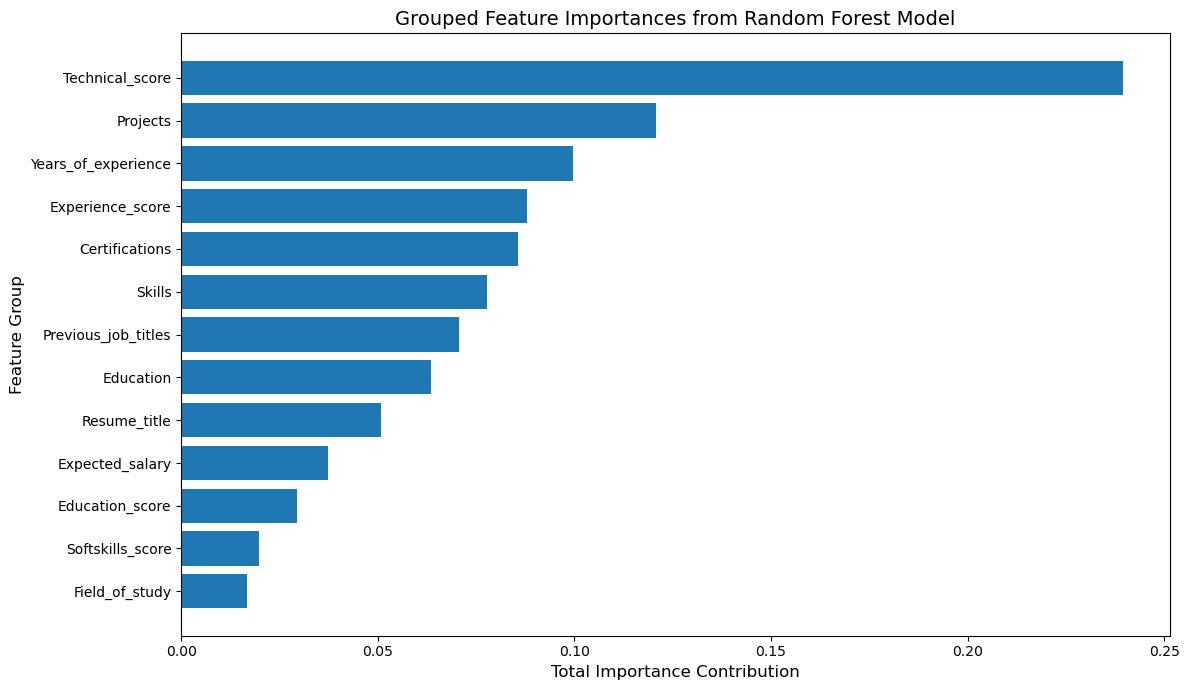

In [66]:
import matplotlib.pyplot as plt

# Ensure grouped_df exists from the previous step
# Sort small → large for a clean horizontal bar chart
plot_df = grouped_df.sort_values("Total_Importance", ascending=True)

plt.figure(figsize=(12, 7))
plt.barh(plot_df["Feature_Group"], plot_df["Total_Importance"])
plt.xlabel("Total Importance Contribution", fontsize=12)
plt.ylabel("Feature Group", fontsize=12)
plt.title("Grouped Feature Importances from Random Forest Model", fontsize=14)
plt.tight_layout()
plt.show()

### Grouping and Visualizing Linear Regression Coefficients

This step analyzes the Linear Regression model by extracting all feature coefficients and mapping them back to their original feature groups. Since categorical variables are expanded into multiple encoded features, their coefficients are summed to show the overall effect of each group. A bar chart is then generated to visualize the relative influence of each feature group on the model’s predictions.


Grouped Linear Regression Coefficients:
                  Group   Coefficient
11      Technical_score  6.234119e+00
4      Experience_score  2.326041e+00
10     Softskills_score  1.094322e+00
12  Years_of_experience  6.226807e-01
2       Education_score  4.778945e-01
9                Skills -1.598721e-13
8          Resume_title -1.922906e-13
6   Previous_job_titles -1.965095e-13
0        Certifications -2.211564e-13
7              Projects -2.646772e-13
5        Field_of_study -6.136203e-13
1             Education -1.068159e-12
3       Expected_salary -5.679582e-02


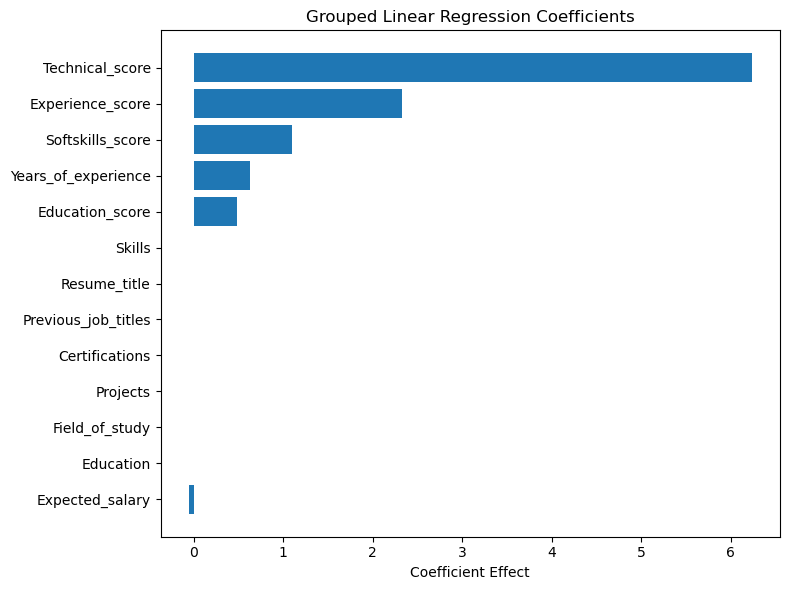

In [78]:
# 1) Get names + coefficients from the fitted LR pipeline
lr_pre = lr_pipe.named_steps["preprocess"]
lr_model = lr_pipe.named_steps["lr"]

all_lr_features = lr_pre.get_feature_names_out()

lr_coef_df = pd.DataFrame({
    "Feature": all_lr_features,
    "Coefficient": lr_model.coef_
})

# 2) Map each transformed feature back to its original group
def group_feature(f):
    if f.startswith("num__"):
        return f.replace("num__", "")
    if f.startswith("cat__Resume_title_"):
        return "Resume_title"
    if f.startswith("cat__Previous_job_titles_"):
        return "Previous_job_titles"
    if f.startswith("cat__Education_"):
        return "Education"
    if f.startswith("cat__Field_of_study_"):
        return "Field_of_study"
    if f.startswith("cat__Skills_"):
        return "Skills"
    if f.startswith("cat__Certifications_"):
        return "Certifications"
    if f.startswith("cat__Projects_"):
        return "Projects"
    return f

lr_coef_df["Group"] = lr_coef_df["Feature"].apply(group_feature)

group_lr_coeffs = (
    lr_coef_df
    .groupby("Group")["Coefficient"]
    .sum()
    .reset_index()
    .sort_values("Coefficient", ascending=False)
)

print("\nGrouped Linear Regression Coefficients:")
print(group_lr_coeffs)

plt.figure(figsize=(8, 6))
plt.barh(group_lr_coeffs["Group"], group_lr_coeffs["Coefficient"])
plt.xlabel("Coefficient Effect")
plt.title("Grouped Linear Regression Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Analyzing Linear Regression Coefficients for Individual Resume Titles

This step focuses specifically on the one-hot encoded Resume_title features from the Linear Regression model. The corresponding coefficients are extracted, cleaned, and sorted to reveal how each title individually influences the predicted score. A horizontal bar chart visualizes the highest and lowest coefficient values, highlighting which resume titles have the strongest positive or negative effects on model predictions.


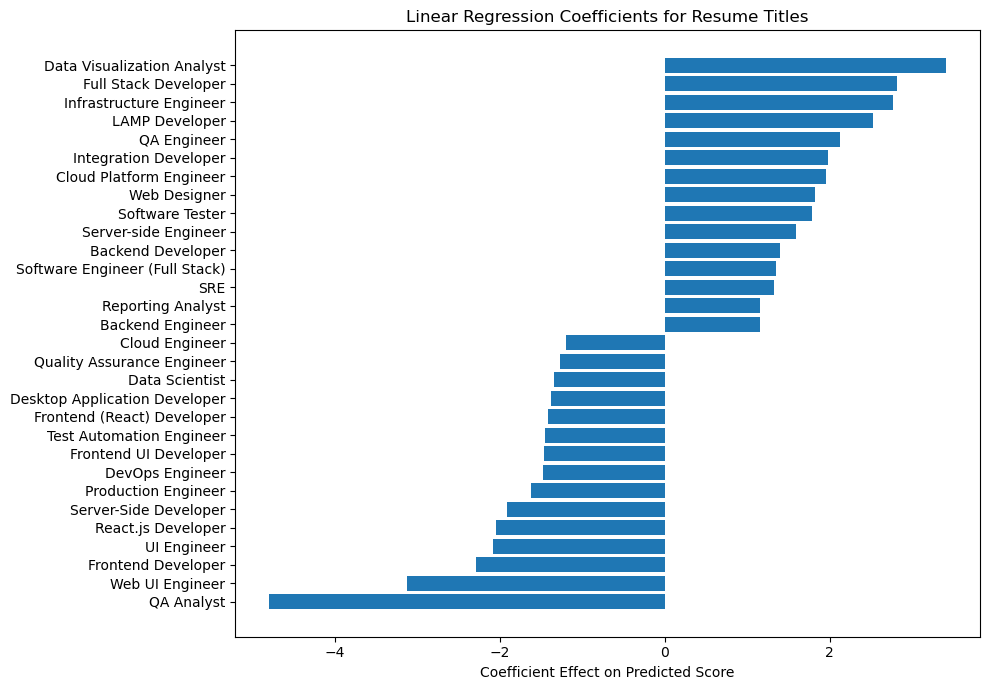


Resume title coefficients (sample):
                                             Feature  Coefficient  \
50                      cat__Resume_title_QA Analyst    -4.796633   
81                 cat__Resume_title_Web UI Engineer    -3.120181   
31              cat__Resume_title_Frontend Developer    -2.291323   
76                     cat__Resume_title_UI Engineer    -2.078380   
56              cat__Resume_title_React.js Developer    -2.041980   
64           cat__Resume_title_Server-Side Developer    -1.907145   
48             cat__Resume_title_Production Engineer    -1.620386   
29                 cat__Resume_title_DevOps Engineer    -1.479876   
33           cat__Resume_title_Frontend UI Developer    -1.465040   
73        cat__Resume_title_Test Automation Engineer    -1.447962   
30      cat__Resume_title_Frontend (React) Developer    -1.417133   
28   cat__Resume_title_Desktop Application Developer    -1.374947   
26                  cat__Resume_title_Data Scientist    -1.342219 

In [80]:
# Filter only Resume_title dummy coefficients
title_coefs = lr_coef_df[lr_coef_df["Feature"].str.startswith("cat__Resume_title_")].copy()

# Clean label: remove prefix
title_coefs["Resume_title_category"] = title_coefs["Feature"].str.replace("cat__Resume_title_", "", regex=False)

# Sort by effect
title_coefs_sorted = title_coefs.sort_values("Coefficient", ascending=True)

# Plot top 15 lowest and top 15 highest
subset = pd.concat([title_coefs_sorted.head(15), title_coefs_sorted.tail(15)])

plt.figure(figsize=(10, 7))
plt.barh(subset["Resume_title_category"], subset["Coefficient"])
plt.xlabel("Coefficient Effect on Predicted Score")
plt.title("Linear Regression Coefficients for Resume Titles")
plt.tight_layout()
plt.show()

print("\nResume title coefficients (sample):")
print(subset)

### Loading the Test Dataset and Inspecting Resume Titles

In this step, the test dataset is loaded to prepare for counterfactual title analysis.  
We also display the unique resume titles present in the test data to understand the range of titles that will be used for generating similar and divergent title variations.


In [84]:
df_test = pd.read_csv("data/test_resume.csv")

# Check unique titles (optional)
print(sorted(df_test["Resume_title"].unique()))

['API Developer', 'API Engineer', 'AWS Engineer', 'App Developer', 'Application Developer', 'Applied Scientist', 'Associate Software Engineer', 'Automation Engineer', 'Azure Engineer', 'BI Analyst', 'BI Analyst (Junior)', 'Backend Developer', 'Backend Engineer', 'Business Analyst (Data)', 'Business Intelligence Analyst', 'C# Developer', 'Cloud Engineer', 'Cloud Platform Engineer', 'Data Analyst', 'Data Science Researcher', 'Data Scientist', 'Data Visualization Analyst', 'Desktop Application Developer', 'DevOps Engineer', 'Frontend (React) Developer', 'Frontend Developer', 'Frontend Engineer', 'Frontend UI Developer', 'Full Stack Developer', 'Full-Stack Engineer', 'Infrastructure Engineer', 'Integration Developer', 'Java Developer', 'JavaScript Developer', 'JavaScript Engineer', 'LAMP Developer', 'MERN Developer', 'ML Engineer', 'Manual Tester', 'Microservices Developer', 'Platform Developer', 'Platform Engineer', 'Production Engineer', 'Programmer', 'QA Analyst', 'QA Automation Enginee

In [92]:
# Create a mapping of each title → its family using get_family()
title_to_family = {
    title: get_family(title)
    for title in df_test["Resume_title"].unique()
}

print("Title → Family mapping:")
for k, v in title_to_family.items():
    print(f"{k}: {v}")

Title → Family mapping:
QA Engineer: QA
Automation Engineer: QA
Software Developer: Software
Java Developer: Other
Backend Engineer: Backend
Application Developer: Software
React Developer: Frontend
Associate Software Engineer: Software
Programmer: Other
Software Engineer: Software
Site Reliability Engineer (SRE): Cloud_DevOps
API Developer: Other
Full Stack Developer: FullStack
Server-Side Developer: Backend
Data Scientist: Data
Frontend Engineer: Frontend
Software Tester: QA
UI Developer: Frontend
Business Intelligence Analyst: Data
Web Designer: Frontend
UI Engineer: Frontend
Web Developer: Frontend
Frontend Developer: Frontend
JavaScript Developer: Other
Cloud Engineer: Cloud_DevOps
Data Analyst: Data
Full-Stack Engineer: FullStack
MERN Developer: Other
Software Engineer (Full Stack): FullStack
LAMP Developer: Other
Software Applications Engineer: Software
C# Developer: Other
Desktop Application Developer: Software
App Developer: Software
DevOps Engineer: Cloud_DevOps
Web UI Engine

In [94]:
def get_family(title: str) -> str:
    t = title.lower()

    # --- QA / Testing / Automation ---
    if any(k in t for k in ["qa", "quality", "tester", "test ", "automation"]):
        return "QA"

    # --- Backend / Server / Microservices ---
    if any(k in t for k in ["backend", "server", "microservices"]):
        return "Backend"

    # --- Frontend / UI / Web / React / SPA ---
    if any(k in t for k in ["frontend", "front-end", "ui", "web", "react", "spa"]):
        return "Frontend"

    # --- Full stack ---
    if "full stack" in t or "full-stack" in t:
        return "FullStack"

    # --- Data / BI / Analytics / Reporting ---
    if any(k in t for k in ["data", "bi ", "bi analyst", "business intelligence",
                            "reporting", "visualization", "analyst"]):
        return "Data"

    # --- Cloud / DevOps / SRE / Platform / Infra ---
    if any(k in t for k in ["cloud", "aws", "azure", "devops", "sre",
                            "site reliability", "platform engineer",
                            "infrastructure", "systems engineer (devops)"]):
        return "Cloud_DevOps"

    # --- ML / Applied Scientist ---
    if any(k in t for k in ["ml ", "machine learning", "applied scientist"]):
        return "ML_AI"

    # --- Generic software / applications / app dev ---
    if any(k in t for k in ["software", "applications engineer", "app developer", "application developer"]):
        return "Software"

    # Fallback
    return "Other"

In [96]:
# ============================================
# STEP 3 — Generate similar & divergent titles for each resume
# ============================================

def get_title_family(title):
    return title_to_family.get(title, None)

similar_list = []
divergent_list = []

for idx, row in df_test.iterrows():
    original = row["Resume_title"]
    family = get_title_family(original)

    if family is None:
        similar_titles = []
        divergent_titles = list(title_to_family.keys())
    else:
        similar_titles = [
            t for t in title_to_family 
            if title_to_family[t] == family and t != original
        ]

        divergent_titles = [
            t for t in title_to_family 
            if title_to_family[t] != family
        ]

    similar_list.append(similar_titles)
    divergent_list.append(divergent_titles)

df_test["Similar_titles"] = similar_list
df_test["Divergent_titles"] = divergent_list

df_test[["Resume_title", "Similar_titles", "Divergent_titles"]].head()

,Resume_title,Similar_titles,Divergent_titles
0,QA Engineer,"[Automation Engineer, Software Tester, QA Test...","[Software Developer, Java Developer, Backend E..."
1,Automation Engineer,"[QA Engineer, Software Tester, QA Tester, QA A...","[Software Developer, Java Developer, Backend E..."
2,Software Developer,"[Application Developer, Associate Software Eng...","[QA Engineer, Automation Engineer, Java Develo..."
3,Java Developer,"[Programmer, API Developer, JavaScript Develop...","[QA Engineer, Automation Engineer, Software De..."
4,Backend Engineer,"[Server-Side Developer, Backend Developer, Ser...","[QA Engineer, Automation Engineer, Software De..."


In [98]:
df_test["family"] = df_test["Resume_title"].apply(get_family)

print(df_test[["Resume_title", "family"]].drop_duplicates().sort_values("Resume_title"))

               Resume_title        family
21            API Developer         Other
719            API Engineer         Other
1403           AWS Engineer  Cloud_DevOps
309           App Developer      Software
5     Application Developer      Software
...                     ...           ...
505     UI Engineer (React)      Frontend
106            Web Designer      Frontend
110           Web Developer      Frontend
614        Web UI Developer      Frontend
401         Web UI Engineer      Frontend

[76 rows x 2 columns]


In [100]:
# All unique titles and families
ALL_TITLES = sorted(df_test["Resume_title"].unique())
ALL_FAMILIES = sorted(df_test["family"].unique())

# Map family -> titles in that family
family_to_titles = {
    fam: sorted(df_test[df_test["family"] == fam]["Resume_title"].unique().tolist())
    for fam in ALL_FAMILIES
}

family_to_titles

{'Backend': ['Backend Developer',
  'Backend Engineer',
  'Microservices Developer',
  'Server Engineer',
  'Server-Side Developer',
  'Server-side Engineer'],
 'Cloud_DevOps': ['AWS Engineer',
  'Azure Engineer',
  'Cloud Engineer',
  'Cloud Platform Engineer',
  'DevOps Engineer',
  'Infrastructure Engineer',
  'Platform Engineer',
  'SRE',
  'Site Reliability Engineer (SRE)',
  'Systems Engineer (DevOps)'],
 'Data': ['BI Analyst',
  'BI Analyst (Junior)',
  'Business Analyst (Data)',
  'Business Intelligence Analyst',
  'Data Analyst',
  'Data Science Researcher',
  'Data Scientist',
  'Data Visualization Analyst',
  'Reporting Analyst',
  'Reporting Analyst (Power BI)'],
 'Frontend': ['Frontend (React) Developer',
  'Frontend Developer',
  'Frontend Engineer',
  'Frontend UI Developer',
  'React Developer',
  'React.js Developer',
  'SPA Developer',
  'UI Developer',
  'UI Engineer',
  'UI Engineer (React)',
  'Web Designer',
  'Web Developer',
  'Web UI Developer',
  'Web UI Engin

In [102]:
def get_similar_and_divergent(title: str):
    fam = get_family(title)

    # Titles in the same family (except itself) = similar
    similar = [t for t in family_to_titles.get(fam, []) if t != title]

    # Titles in other families = divergent
    divergent = [t for t in ALL_TITLES if t not in family_to_titles.get(fam, [])]

    return similar, divergent

In [104]:
df_test["Similar_titles"] = df_test["Resume_title"].apply(
    lambda x: get_similar_and_divergent(x)[0]
)
df_test["Divergent_titles"] = df_test["Resume_title"].apply(
    lambda x: get_similar_and_divergent(x)[1]
)

In [106]:
df_test[df_test["Resume_title"] == "Automation Engineer"][["Resume_title", "Similar_titles", "Divergent_titles"]].head()


,Resume_title,Similar_titles,Divergent_titles
1,Automation Engineer,"[Manual Tester, QA Analyst, QA Automation Engi...","[API Developer, API Engineer, AWS Engineer, Ap..."
32,Automation Engineer,"[Manual Tester, QA Analyst, QA Automation Engi...","[API Developer, API Engineer, AWS Engineer, Ap..."
109,Automation Engineer,"[Manual Tester, QA Analyst, QA Automation Engi...","[API Developer, API Engineer, AWS Engineer, Ap..."
175,Automation Engineer,"[Manual Tester, QA Analyst, QA Automation Engi...","[API Developer, API Engineer, AWS Engineer, Ap..."
182,Automation Engineer,"[Manual Tester, QA Analyst, QA Automation Engi...","[API Developer, API Engineer, AWS Engineer, Ap..."


In [108]:
print("Number of test rows:", len(df_test))

# Optional: check average length of similar/divergent lists
print("Avg similar titles:", df_test["Similar_titles"].apply(len).mean())
print("Avg divergent titles:", df_test["Divergent_titles"].apply(len).mean())

Number of test rows: 1900
Avg similar titles: 9.233157894736841
Avg divergent titles: 65.76684210526315


In [110]:
import pandas as pd
import time
from copy import deepcopy

counterfactual_rows = []

start_all = time.time()
n_rows = len(df_test)

for idx, row in df_test.iterrows():
    row_start = time.time()

    orig_title = row["Resume_title"]
    sim_titles = row["Similar_titles"]
    div_titles = row["Divergent_titles"][:10]  # limit divergent

    # ----------------------------------------
    # Compute ORIGINAL prediction only ONCE
    # ----------------------------------------
    X_orig = row[resume_features].to_frame().T
    rf_pred_orig = grid.predict(X_orig)[0]
    lr_pred_orig = lr_pipe.predict(X_orig)[0]

    # -------------------------
    # SIMILAR titles
    # -------------------------
    inner_start = time.time()
    for new_title in sim_titles:
        new_row = row.copy()
        new_row["Resume_title"] = new_title
        
        X_cf = new_row[resume_features].to_frame().T

        rf_pred_new = grid.predict(X_cf)[0]
        lr_pred_new = lr_pipe.predict(X_cf)[0]

        counterfactual_rows.append({
            "Row_ID": idx,
            "Original_title": orig_title,
            "Changed_title": new_title,
            "Type": "Similar",
            "RF_diff": rf_pred_new - rf_pred_orig,
            "LR_diff": lr_pred_new - lr_pred_orig,
        })

    # -------------------------
    # DIVERGENT titles
    # -------------------------
    for new_title in div_titles:
        new_row = row.copy()
        new_row["Resume_title"] = new_title

        X_cf = new_row[resume_features].to_frame().T

        rf_pred_new = grid.predict(X_cf)[0]
        lr_pred_new = lr_pipe.predict(X_cf)[0]

        counterfactual_rows.append({
            "Row_ID": idx,
            "Original_title": orig_title,
            "Changed_title": new_title,
            "Type": "Divergent",
            "RF_diff": rf_pred_new - rf_pred_orig,
            "LR_diff": lr_pred_new - lr_pred_orig,
        })

    inner_time = time.time() - inner_start
    row_time = time.time() - row_start
    elapsed = time.time() - start_all
    remaining = (n_rows - (idx + 1)) * row_time

    print(
        f"Row {idx+1}/{n_rows} | "
        f"Row time: {row_time:.3f}s | "
        f"Inner: {inner_time:.3f}s | "
        f"Elapsed: {elapsed/60:.1f} min | "
        f"ETA: {remaining/60:.1f} min"
    )

# Build dataframe
cf_df = pd.DataFrame(counterfactual_rows)
cf_df.head()

Row 1/1900 | Row time: 0.292s | Inner: 0.266s | Elapsed: 0.0 min | ETA: 9.2 min
Row 2/1900 | Row time: 0.262s | Inner: 0.250s | Elapsed: 0.0 min | ETA: 8.3 min
Row 3/1900 | Row time: 0.194s | Inner: 0.182s | Elapsed: 0.0 min | ETA: 6.1 min
Row 4/1900 | Row time: 0.267s | Inner: 0.255s | Elapsed: 0.0 min | ETA: 8.4 min
Row 5/1900 | Row time: 0.169s | Inner: 0.158s | Elapsed: 0.0 min | ETA: 5.3 min
Row 6/1900 | Row time: 0.195s | Inner: 0.184s | Elapsed: 0.0 min | ETA: 6.2 min
Row 7/1900 | Row time: 0.255s | Inner: 0.244s | Elapsed: 0.0 min | ETA: 8.0 min
Row 8/1900 | Row time: 0.185s | Inner: 0.171s | Elapsed: 0.0 min | ETA: 5.8 min
Row 9/1900 | Row time: 0.263s | Inner: 0.253s | Elapsed: 0.0 min | ETA: 8.3 min
Row 10/1900 | Row time: 0.255s | Inner: 0.244s | Elapsed: 0.0 min | ETA: 8.0 min
Row 11/1900 | Row time: 0.233s | Inner: 0.220s | Elapsed: 0.0 min | ETA: 7.3 min
Row 12/1900 | Row time: 0.287s | Inner: 0.276s | Elapsed: 0.0 min | ETA: 9.0 min
Row 13/1900 | Row time: 0.178s | Inne

,Row_ID,Original_title,Changed_title,Type,RF_diff,LR_diff
0,0,QA Engineer,Automation Engineer,Similar,0.204943,-2.566813
1,0,QA Engineer,Manual Tester,Similar,-0.680370,-2.851612
2,0,QA Engineer,QA Analyst,Similar,-0.012149,-6.925226
3,0,QA Engineer,QA Automation Engineer,Similar,0.246124,-2.394968
4,0,QA Engineer,QA Tester,Similar,-0.018200,-2.622976


### Measuring Average Bias for Each Changed Title

This step groups all counterfactual results by the *changed* resume title to calculate how much each substituted title shifts the predicted score on average.  
By comparing the mean Random Forest and Linear Regression score differences (`RF_diff` and `LR_diff`), we identify which titles tend to increase or decrease predictions the most when used in place of the original title.


In [162]:
bias_by_changed = cf_df.groupby("Changed_title")[["RF_diff", "LR_diff"]].mean().sort_values("RF_diff")
bias_by_changed

,RF_diff,LR_diff
Changed_title,,
Associate Software Engineer,-0.566743,0.444170
Web UI Engineer,-0.502828,-2.536664
Infrastructure Engineer,-0.482087,2.765083
Applied Scientist,-0.408228,-0.628298
Manual Tester,-0.392343,-0.972967
Frontend Developer,-0.314063,-1.720395
Full-Stack Engineer,-0.296132,-1.590584
SPA Developer,-0.291473,1.517153
Quality Assurance Engineer,-0.272671,-1.559640


### Comparing Bias Between Similar and Divergent Title Changes

This step groups the counterfactual results by the type of title change—**Similar** vs **Divergent**—and computes the average score differences for both models.  
This helps determine whether replacing a resume title with a closely related title produces smaller shifts compared to replacing it with a completely different or unrelated title.


In [112]:
bias_by_type = cf_df.groupby("Type")[["RF_diff", "LR_diff"]].mean()
bias_by_type

,RF_diff,LR_diff
Type,,
Divergent,-0.067931,-0.168256
Similar,-0.018829,-0.006997


### Visualizing Bias Distribution for Similar vs Divergent Title Changes (Random Forest)

This step uses a boxplot to compare how Random Forest score differences (`RF_diff`) vary between **Similar** and **Divergent** title changes.  
The visualization highlights the spread, median, and outliers in the bias distribution, helping identify whether divergent titles le


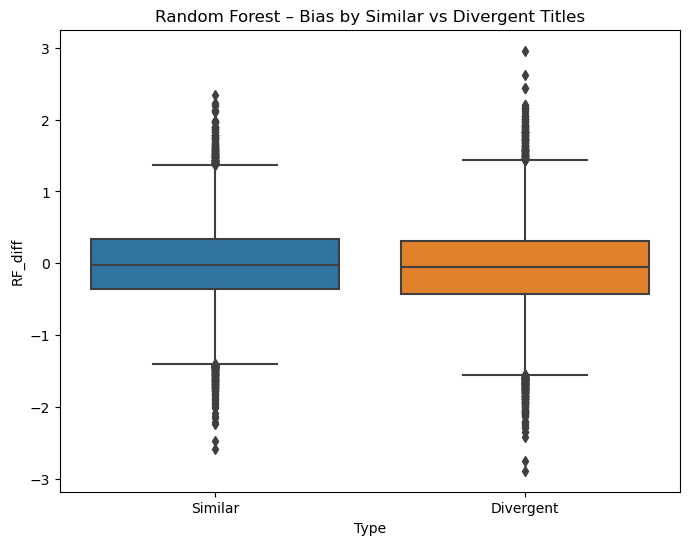

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=cf_df, x="Type", y="RF_diff")
plt.title("Random Forest – Bias by Similar vs Divergent Titles")
plt.show()

### Visualizing Bias Distribution for Similar vs Divergent Title Changes (Linear Regression)

This boxplot illustrates how Linear Regression score differences (`LR_diff`) vary between **Similar** and **Divergent** title substitutions.  
It helps compare whether the model reacts more strongly to divergent title changes, and whether its behavior is consistent with the Random Forest model.


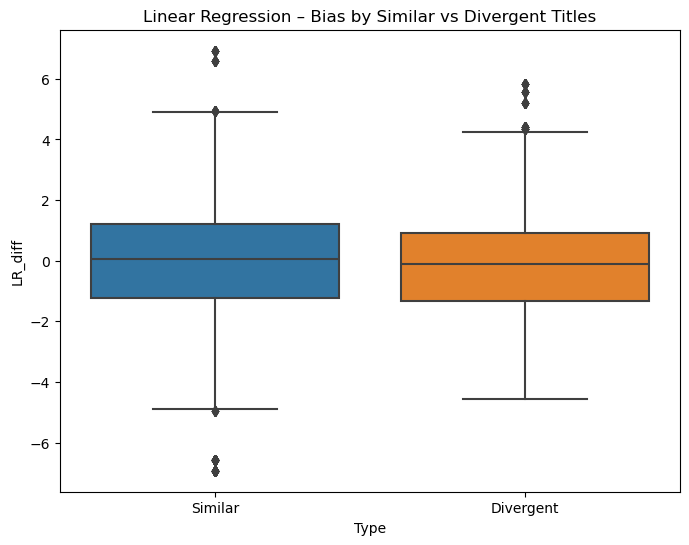

In [114]:
plt.figure(figsize=(8,6))
sns.boxplot(data=cf_df, x="Type", y="LR_diff")
plt.title("Linear Regression – Bias by Similar vs Divergent Titles")
plt.show()

### Visualizing Average Random Forest Bias for Each Changed Title

This horizontal bar chart shows the average score shift (`RF_diff`) caused by substituting each resume title in the counterfactual analysis.  
It highlights which titles consistently increase or decrease model predictions the most, helping identify titles that exert strong po

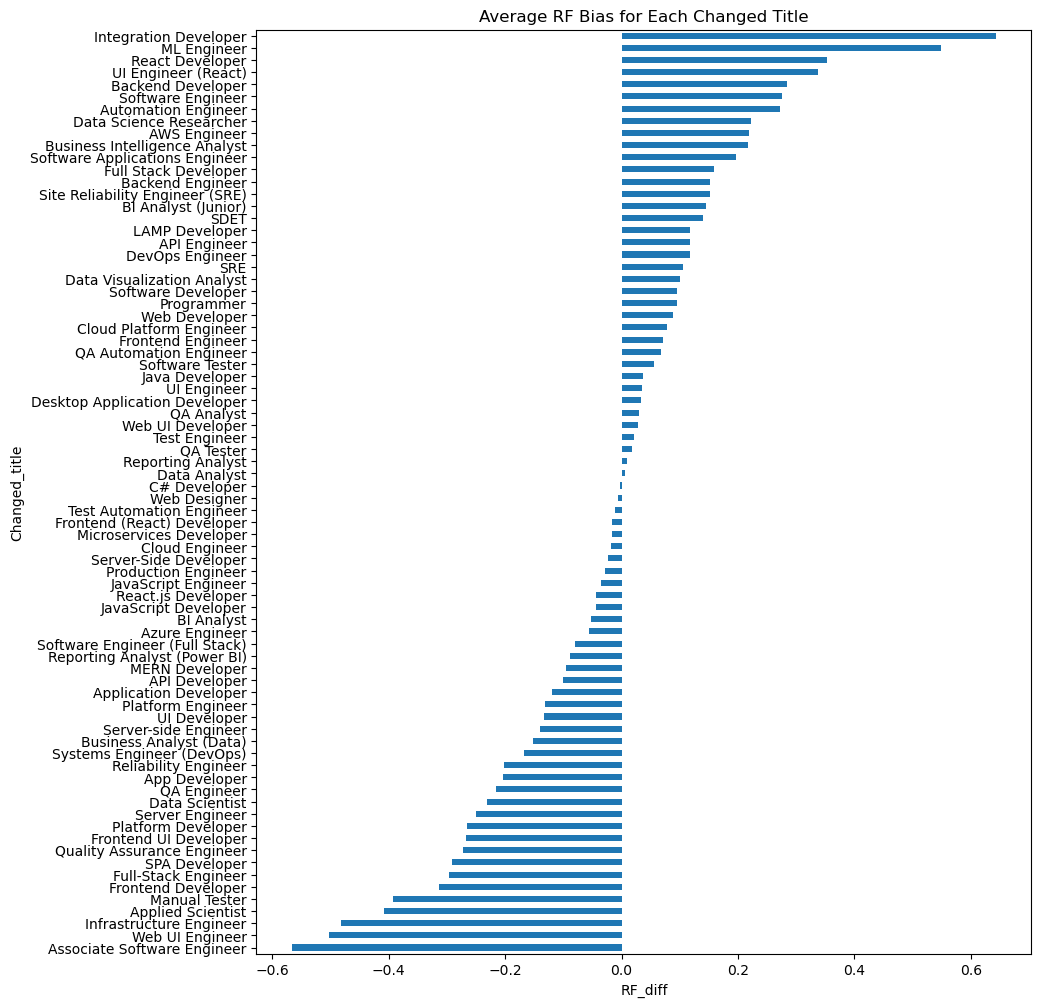

In [115]:
plt.figure(figsize=(10,12))
bias_by_changed["RF_diff"].plot(kind="barh")
plt.title("Average RF Bias for Each Changed Title")
plt.xlabel("RF_diff")
plt.show()


In [116]:
# Largest negative LR bias
most_negative_lr = cf_df.loc[cf_df["LR_diff"].idxmin()]

# Largest positive LR bias
most_positive_lr = cf_df.loc[cf_df["LR_diff"].idxmax()]

# Largest negative RF bias
most_negative_rf = cf_df.loc[cf_df["RF_diff"].idxmin()]

# Largest positive RF bias
most_positive_rf = cf_df.loc[cf_df["RF_diff"].idxmax()]

most_negative_lr, most_positive_lr, most_negative_rf, most_positive_rf

(Row_ID                    486
 Original_title    QA Engineer
 Changed_title      QA Analyst
 Type                  Similar
 RF_diff               0.34895
 LR_diff             -6.925226
 Name: 9433, dtype: object,
 Row_ID                   1663
 Original_title     QA Analyst
 Changed_title     QA Engineer
 Type                  Similar
 RF_diff              0.026276
 LR_diff              6.925226
 Name: 32014, dtype: object,
 Row_ID                                    836
 Original_title          Integration Developer
 Changed_title     Associate Software Engineer
 Type                                Divergent
 RF_diff                             -2.887292
 LR_diff                             -1.588015
 Name: 16628, dtype: object,
 Row_ID                            978
 Original_title        Server Engineer
 Changed_title     Automation Engineer
 Type                        Divergent
 RF_diff                       2.95977
 LR_diff                     -0.969781
 Name: 19191, dtype: objec

### Generating a Bias Summary for a Specific Resume Title

This step defines a function that produces a detailed bias summary for any selected resume title.  
For the given title, the function separates **Similar** and **Divergent** counterfactual cases and computes:

- The number of comparisons generated  
- The average score shift for Similar vs. Divergent substitutions for both models  
- The titles that cause the highest and lowest Random Forest bias, along with the magnitude  

Calling the function (e.g., for *“QA Engineer”*) returns a concise table summarizing how sensitive the model is to changes from that specific original title.

In [117]:
def title_bias_summary(title):
    subset = cf_df[cf_df["Original_title"] == title]

    if subset.empty:
        print("Title not found in cf_df.")
        return

    similar = subset[subset["Type"] == "Similar"]
    divergent = subset[subset["Type"] == "Divergent"]

    summary = {
        "Original Title": title,
        "Similar_count": len(similar),
        "Divergent_count": len(divergent),

        # Random Forest
        "RF_avg_similar": similar["RF_diff"].mean(),
        "RF_avg_divergent": divergent["RF_diff"].mean(),

        # Linear Regression
        "LR_avg_similar": similar["LR_diff"].mean(),
        "LR_avg_divergent": divergent["LR_diff"].mean(),

        # Max bias cases
        "Max_RF_bias_title": subset.loc[subset["RF_diff"].idxmax()]["Changed_title"],
        "Max_RF_bias_value": subset["RF_diff"].max(),
        "Min_RF_bias_title": subset.loc[subset["RF_diff"].idxmin()]["Changed_title"],
        "Min_RF_bias_value": subset["RF_diff"].min(),
    }

    return pd.DataFrame([summary])

# Example for QA Engineer
title_bias_summary("QA Engineer")

,Original Title,Similar_count,Divergent_count,RF_avg_similar,RF_avg_divergent,LR_avg_similar,LR_avg_divergent,Max_RF_bias_title,Max_RF_bias_value,Min_RF_bias_title,Min_RF_bias_value
0,QA Engineer,495,550,0.167226,0.056738,-2.967586,-2.424473,Automation Engineer,1.477355,App Developer,-1.861341


In [118]:
df_test[["Resume_title", "Similar_titles", "Divergent_titles"]].head(10)

,Resume_title,Similar_titles,Divergent_titles
0,QA Engineer,"[Automation Engineer, Manual Tester, QA Analys...","[API Developer, API Engineer, AWS Engineer, Ap..."
1,Automation Engineer,"[Manual Tester, QA Analyst, QA Automation Engi...","[API Developer, API Engineer, AWS Engineer, Ap..."
2,Software Developer,"[App Developer, Application Developer, Associa...","[API Developer, API Engineer, AWS Engineer, Ap..."
3,Java Developer,"[API Developer, API Engineer, C# Developer, In...","[AWS Engineer, App Developer, Application Deve..."
4,Backend Engineer,"[Backend Developer, Microservices Developer, S...","[API Developer, API Engineer, AWS Engineer, Ap..."
5,Application Developer,"[App Developer, Associate Software Engineer, D...","[API Developer, API Engineer, AWS Engineer, Ap..."
6,React Developer,"[Frontend (React) Developer, Frontend Develope...","[API Developer, API Engineer, AWS Engineer, Ap..."
7,Associate Software Engineer,"[App Developer, Application Developer, Desktop...","[API Developer, API Engineer, AWS Engineer, Ap..."
8,Programmer,"[API Developer, API Engineer, C# Developer, In...","[AWS Engineer, App Developer, Application Deve..."
9,Programmer,"[API Developer, API Engineer, C# Developer, In...","[AWS Engineer, App Developer, Application Deve..."


In [119]:
def title_bias_summary(title):
    subset = cf_df[cf_df["Original_title"] == title]

    if subset.empty:
        print("Title not found in cf_df.")
        return

    similar = subset[subset["Type"] == "Similar"]
    divergent = subset[subset["Type"] == "Divergent"]

    # Collect the changed titles tested
    similar_list = sorted(similar["Changed_title"].unique().tolist())
    divergent_list = sorted(divergent["Changed_title"].unique().tolist())

    summary = {
        "Original Title": title,
        "Similar_count": len(similar),
        "Divergent_count": len(divergent),

        # Random Forest
        "RF_avg_similar": similar["RF_diff"].mean(),
        "RF_avg_divergent": divergent["RF_diff"].mean(),

        # Linear Regression
        "LR_avg_similar": similar["LR_diff"].mean(),
        "LR_avg_divergent": divergent["LR_diff"].mean(),

        # Max bias cases
        "Max_RF_bias_title": subset.loc[subset["RF_diff"].idxmax()]["Changed_title"],
        "Max_RF_bias_value": subset["RF_diff"].max(),
        "Min_RF_bias_title": subset.loc[subset["RF_diff"].idxmin()]["Changed_title"],
        "Min_RF_bias_value": subset["RF_diff"].min(),
    }

    summary_df = pd.DataFrame([summary])

    return summary_df, similar_list, divergent_list

In [120]:
summary, sim_titles, div_titles = title_bias_summary("QA Engineer")
summary

,Original Title,Similar_count,Divergent_count,RF_avg_similar,RF_avg_divergent,LR_avg_similar,LR_avg_divergent,Max_RF_bias_title,Max_RF_bias_value,Min_RF_bias_title,Min_RF_bias_value
0,QA Engineer,495,550,0.167226,0.056738,-2.967586,-2.424473,Automation Engineer,1.477355,App Developer,-1.861341


In [121]:
summary, sim, div = title_bias_summary("QA Engineer")

print("Similar Titles Tested:")
print(sim)
print("\nDivergent Titles Tested:")
print(div)

summary

Similar Titles Tested:
['Automation Engineer', 'Manual Tester', 'QA Analyst', 'QA Automation Engineer', 'QA Tester', 'Quality Assurance Engineer', 'Software Tester', 'Test Automation Engineer', 'Test Engineer']

Divergent Titles Tested:
['API Developer', 'API Engineer', 'AWS Engineer', 'App Developer', 'Application Developer', 'Applied Scientist', 'Associate Software Engineer', 'Azure Engineer', 'BI Analyst', 'BI Analyst (Junior)']


,Original Title,Similar_count,Divergent_count,RF_avg_similar,RF_avg_divergent,LR_avg_similar,LR_avg_divergent,Max_RF_bias_title,Max_RF_bias_value,Min_RF_bias_title,Min_RF_bias_value
0,QA Engineer,495,550,0.167226,0.056738,-2.967586,-2.424473,Automation Engineer,1.477355,App Developer,-1.861341


### Viewing Detailed Bias Scores for Every Title Substitution

This function generates a table showing how each specific changed title affects the model’s predictions for a chosen original title.  
For the selected title, all counterfactual substitutions are grouped by the changed title and type (Similar or Divergent), and the average score differences are calculated for both models.  
The resulting table helps identify which alternative titles cause stronger positive or negative shifts.



In [122]:
def per_title_change_table(title):
    subset = cf_df[cf_df["Original_title"] == title]
    changes = (
        subset.groupby(["Changed_title", "Type"])[["RF_diff", "LR_diff"]]
        .mean()
        .reset_index()
        .sort_values("RF_diff")
    )
    return changes

per_title_change_table("QA Engineer")

,Changed_title,Type,RF_diff,LR_diff
6,Associate Software Engineer,Divergent,-0.331147,-1.732979
5,Applied Scientist,Divergent,-0.254619,-2.797214
11,Manual Tester,Similar,-0.129161,-2.851612
15,Quality Assurance Engineer,Similar,-0.034131,-3.396427
3,App Developer,Divergent,-0.002802,-2.997225
4,Application Developer,Divergent,0.012407,-2.575220
0,API Developer,Divergent,0.079802,-3.250786
8,Azure Engineer,Divergent,0.111101,-3.263150
9,BI Analyst,Divergent,0.129505,-2.683448
17,Test Automation Engineer,Similar,0.137269,-3.576556


### Visualizing Bias Impact for Selected Title Substitutions

This step plots the Random Forest score changes (`RF_diff`) for a chosen original title against a selected list of important or frequently used alternative titles.  
By focusing on a curated subset of titles, the chart clearly highlights which substitutions produce the strongest positive or negative bias, and whether they fall under Similar or Divergent categories.  
This targeted view helps interpret title-specific sensitivity in a more meaningful and readable way.


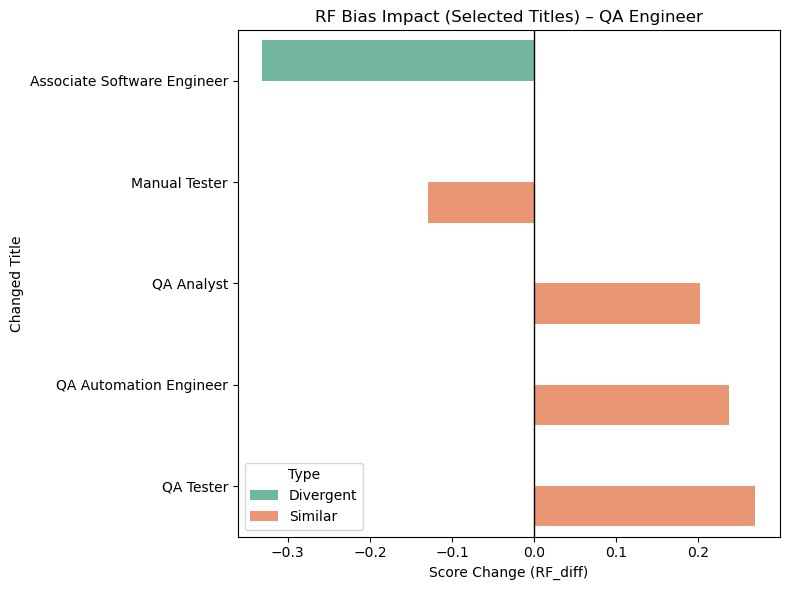

In [123]:
important_titles = [
    "QA Analyst", "QA Tester", "QA Automation Engineer", "Manual Tester",
    "Software Developer", "Software Engineer", "Full Stack Developer",
    "Backend Engineer", "Data Scientist", "Associate Software Engineer"
]

def plot_bias_selected(title, selected_titles):
    df_plot = per_title_change_table(title)
    df_small = df_plot[df_plot["Changed_title"].isin(selected_titles)].copy()
    df_small = df_small.sort_values("RF_diff")

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=df_small,
        x="RF_diff",
        y="Changed_title",
        hue="Type",
        palette="Set2"
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"RF Bias Impact (Selected Titles) – {title}")
    plt.xlabel("Score Change (RF_diff)")
    plt.ylabel("Changed Title")
    plt.tight_layout()
    plt.show()

plot_bias_selected("QA Engineer", important_titles)

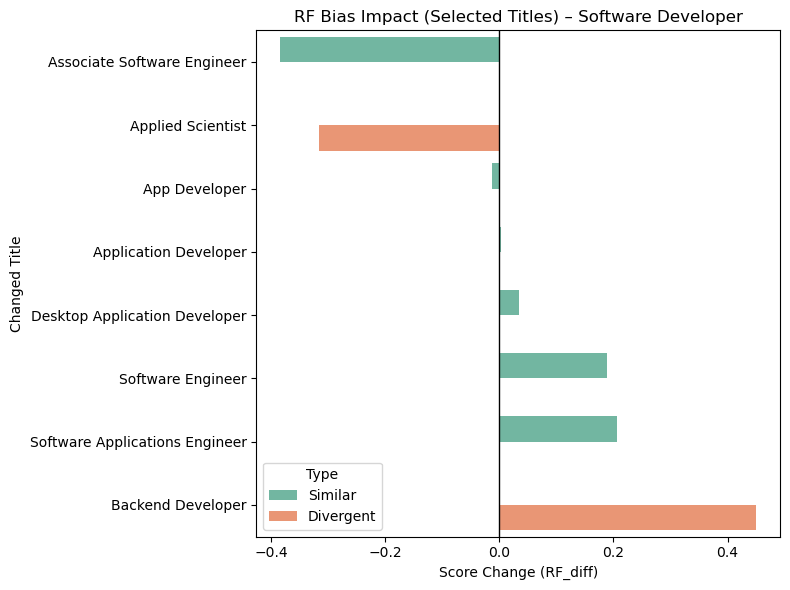

In [124]:
important_titles_dev = [
    'App Developer', 'Application Developer', 'Associate Software Engineer', 'Backend Developer','Desktop Application Developer', 'Software Applications Engineer', 'Software Engineer','Applied Scientist'
]

plot_bias_selected("Software Developer", important_titles_dev)

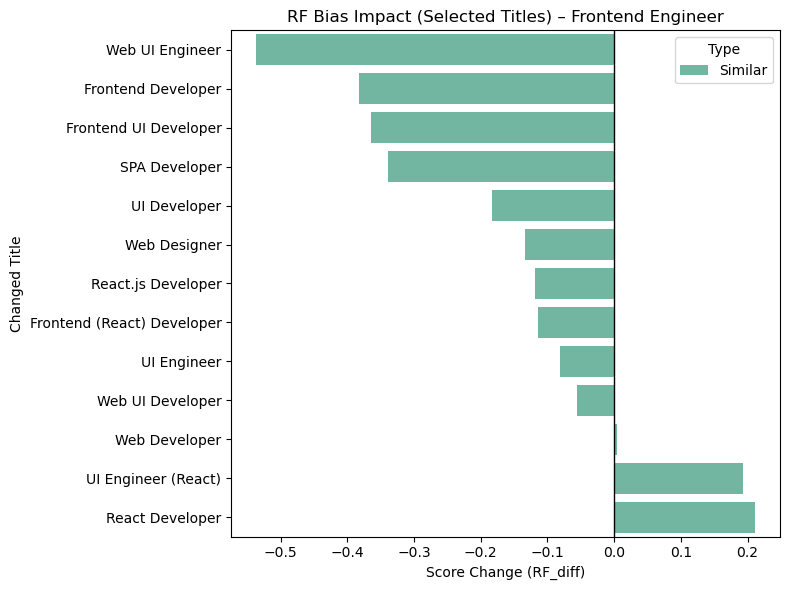

In [125]:
important_titles_dev = [
    'Frontend (React) Developer', 'Frontend Developer', 'Frontend UI Developer', 'React Developer', 'React.js Developer', 'SPA Developer', 'UI Developer', 'UI Engineer', 'UI Engineer (React)', 'Web Designer', 'Web Developer', 'Web UI Developer', 'Web UI Engineer',
]

plot_bias_selected("Frontend Engineer", important_titles_dev)

### Comparing Title Bias Across Multiple Core Roles

This step creates a multi-panel visualization to compare how Random Forest score differences (`RF_diff`) behave for several key original roles (e.g., *QA Engineer*, *Software Developer*, *Frontend Engineer*).  

For each role, only a selected set of important alternative titles is plotted, with bars showing how much each substitution changes the predicted score and whether it is classified as a Similar or Divergent change. This side-by-side view helps reveal consistent patterns of bias across different core roles in the tech hiring context.


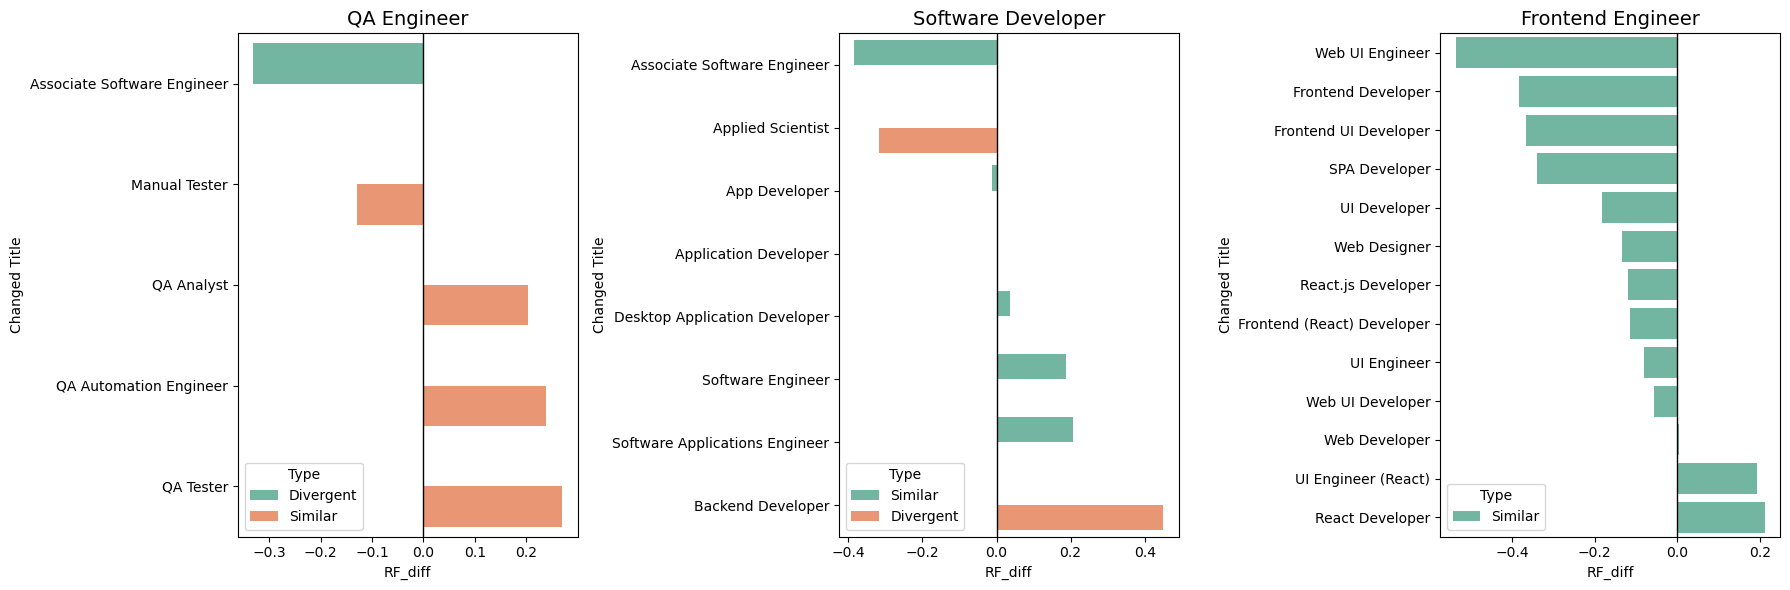

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_bias_multi(roles, selected_titles_dict):
    fig, axes = plt.subplots(1, len(roles), figsize=(18, 6), sharex=False)

    for i, role in enumerate(roles):
        df_plot = per_title_change_table(role)

        # Filter only important titles for this role
        selected_titles = selected_titles_dict[role]
        df_small = df_plot[df_plot["Changed_title"].isin(selected_titles)].copy()
        df_small = df_small.sort_values("RF_diff")

        sns.barplot(
            data=df_small,
            x="RF_diff",
            y="Changed_title",
            hue="Type",
            palette="Set2",
            ax=axes[i]
        )

        axes[i].axvline(0, color="black", linewidth=1)
        axes[i].set_title(f"{role}", fontsize=14)
        axes[i].set_xlabel("RF_diff")
        axes[i].set_ylabel("Changed Title")

    plt.tight_layout()
    plt.show()


# ----------------------------------------
# Dictionary of important titles PER ROLE
# ----------------------------------------

important_titles = {
    "QA Engineer": [
        "QA Analyst", "QA Tester", "QA Automation Engineer", "Manual Tester",
        "Software Developer", "Software Engineer", "Full Stack Developer",
        "Backend Engineer", "Data Scientist", "Associate Software Engineer"
    ],

    "Software Developer": [
        'App Developer', 'Application Developer', 'Associate Software Engineer',
        'Backend Developer', 'Desktop Application Developer',
        'Software Applications Engineer', 'Software Engineer',
        'Applied Scientist'
    ],

    "Frontend Engineer": [
        'Frontend (React) Developer', 'Frontend Developer', 'Frontend UI Developer',
        'React Developer', 'React.js Developer', 'SPA Developer', 'UI Developer',
        'UI Engineer', 'UI Engineer (React)', 'Web Designer', 'Web Developer',
        'Web UI Developer', 'Web UI Engineer'
    ]
}

# ----------------------------------------
# RUN FINAL MULTI-PLOT FIGURE
# ----------------------------------------
plot_bias_multi(
    roles=["QA Engineer", "Software Developer", "Frontend Engineer"],
    selected_titles_dict=important_titles
)

In [221]:
pd.set_option("display.max_rows", None)          # show all rows
pd.set_option("display.max_colwidth", None)      # don't cut long text/lists
pd.set_option("display.max_columns", None)  
df_test[["Resume_title", "Similar_titles", "Divergent_titles"]].head(5)

,Resume_title,Similar_titles,Divergent_titles
0,QA Engineer,"[Automation Engineer, Manual Tester, QA Analyst, QA Automation Engineer, QA Tester, Quality Assurance Engineer, Software Tester, Test Automation Engineer, Test Engineer]","[API Developer, API Engineer, AWS Engineer, App Developer, Application Developer, Applied Scientist, Associate Software Engineer, Azure Engineer, BI Analyst, BI Analyst (Junior), Backend Developer, Backend Engineer, Business Analyst (Data), Business Intelligence Analyst, C# Developer, Cloud Engineer, Cloud Platform Engineer, Data Analyst, Data Science Researcher, Data Scientist, Data Visualization Analyst, Desktop Application Developer, DevOps Engineer, Frontend (React) Developer, Frontend Developer, Frontend Engineer, Frontend UI Developer, Full Stack Developer, Full-Stack Engineer, Infrastructure Engineer, Integration Developer, Java Developer, JavaScript Developer, JavaScript Engineer, LAMP Developer, MERN Developer, ML Engineer, Microservices Developer, Platform Developer, Platform Engineer, Production Engineer, Programmer, React Developer, React.js Developer, Reliability Engineer, Reporting Analyst, Reporting Analyst (Power BI), SDET, SPA Developer, SRE, Server Engineer, Server-Side Developer, Server-side Engineer, Site Reliability Engineer (SRE), Software Applications Engineer, Software Developer, Software Engineer, Software Engineer (Full Stack), Systems Engineer (DevOps), UI Developer, UI Engineer, UI Engineer (React), Web Designer, Web Developer, Web UI Developer, Web UI Engineer]"
1,Automation Engineer,"[Manual Tester, QA Analyst, QA Automation Engineer, QA Engineer, QA Tester, Quality Assurance Engineer, Software Tester, Test Automation Engineer, Test Engineer]","[API Developer, API Engineer, AWS Engineer, App Developer, Application Developer, Applied Scientist, Associate Software Engineer, Azure Engineer, BI Analyst, BI Analyst (Junior), Backend Developer, Backend Engineer, Business Analyst (Data), Business Intelligence Analyst, C# Developer, Cloud Engineer, Cloud Platform Engineer, Data Analyst, Data Science Researcher, Data Scientist, Data Visualization Analyst, Desktop Application Developer, DevOps Engineer, Frontend (React) Developer, Frontend Developer, Frontend Engineer, Frontend UI Developer, Full Stack Developer, Full-Stack Engineer, Infrastructure Engineer, Integration Developer, Java Developer, JavaScript Developer, JavaScript Engineer, LAMP Developer, MERN Developer, ML Engineer, Microservices Developer, Platform Developer, Platform Engineer, Production Engineer, Programmer, React Developer, React.js Developer, Reliability Engineer, Reporting Analyst, Reporting Analyst (Power BI), SDET, SPA Developer, SRE, Server Engineer, Server-Side Developer, Server-side Engineer, Site Reliability Engineer (SRE), Software Applications Engineer, Software Developer, Software Engineer, Software Engineer (Full Stack), Systems Engineer (DevOps), UI Developer, UI Engineer, UI Engineer (React), Web Designer, Web Developer, Web UI Developer, Web UI Engineer]"
2,Software Developer,"[App Developer, Application Developer, Associate Software Engineer, Desktop Application Developer, Software Applications Engineer, Software Engineer]","[API Developer, API Engineer, AWS Engineer, Applied Scientist, Automation Engineer, Azure Engineer, BI Analyst, BI Analyst (Junior), Backend Developer, Backend Engineer, Business Analyst (Data), Business Intelligence Analyst, C# Developer, Cloud Engineer, Cloud Platform Engineer, Data Analyst, Data Science Researcher, Data Scientist, Data Visualization Analyst, DevOps Engineer, Frontend (React) Developer, Frontend Developer, Frontend Engineer, Frontend UI Developer, Full Stack Developer, Full-Stack Engineer, Infrastructure Engineer, Integration Developer, Java Developer, JavaScript Developer, JavaScript Engineer, LAMP Developer, MERN Developer, ML Engineer, Manual Tester, Microservices Developer, Platform Developer, Platform Engineer, Production Engineer, Programmer, QA A

In [128]:
summary, sim, div = title_bias_summary("Frontend Engineer")

print("Similar Titles Tested:")
print(sim)
print("\nDivergent Titles Tested:")
print(div)

summary

Similar Titles Tested:
['Frontend (React) Developer', 'Frontend Developer', 'Frontend UI Developer', 'React Developer', 'React.js Developer', 'SPA Developer', 'UI Developer', 'UI Engineer', 'UI Engineer (React)', 'Web Designer', 'Web Developer', 'Web UI Developer', 'Web UI Engineer']

Divergent Titles Tested:
['API Developer', 'API Engineer', 'AWS Engineer', 'App Developer', 'Application Developer', 'Applied Scientist', 'Associate Software Engineer', 'Automation Engineer', 'Azure Engineer', 'BI Analyst']


,Original Title,Similar_count,Divergent_count,RF_avg_similar,RF_avg_divergent,LR_avg_similar,LR_avg_divergent,Max_RF_bias_title,Max_RF_bias_value,Min_RF_bias_title,Min_RF_bias_value
0,Frontend Engineer,689,530,-0.146093,-0.177274,-1.231963,-0.605698,Automation Engineer,1.459981,App Developer,-2.046507


### Viewing Bias Scores for All Title Substitutions for a Specific Role

This step generates a detailed table showing how each substituted title affects the model’s predictions for the selected original role.  
For *Frontend Engineer*, all counterfactual changes are grouped by the changed title and type (Similar or Divergent), and the average score differences for both models are calculated.  
The table helps identify which alternative titles lead to strong positive or negative shifts, revealing how sensitive the model is to title changes for this specific role.


In [129]:
def per_title_change_table(title):
    subset = cf_df[cf_df["Original_title"] == title]
    changes = (
        subset.groupby(["Changed_title", "Type"])[["RF_diff", "LR_diff"]]
        .mean()
        .reset_index()
        .sort_values("RF_diff")
    )
    return changes

per_title_change_table("Frontend Engineer")

,Changed_title,Type,RF_diff,LR_diff
6,Associate Software Engineer,Divergent,-0.603675,0.091060
22,Web UI Engineer,Similar,-0.536577,-3.424736
5,Applied Scientist,Divergent,-0.521937,-0.973175
11,Frontend Developer,Similar,-0.381903,-2.595879
12,Frontend UI Developer,Similar,-0.365006,-1.769595
15,SPA Developer,Similar,-0.338541,0.496826
3,App Developer,Divergent,-0.318349,-1.173187
4,Application Developer,Divergent,-0.226491,-0.751181
0,API Developer,Divergent,-0.205198,-1.426748
16,UI Developer,Similar,-0.182624,-1.186285


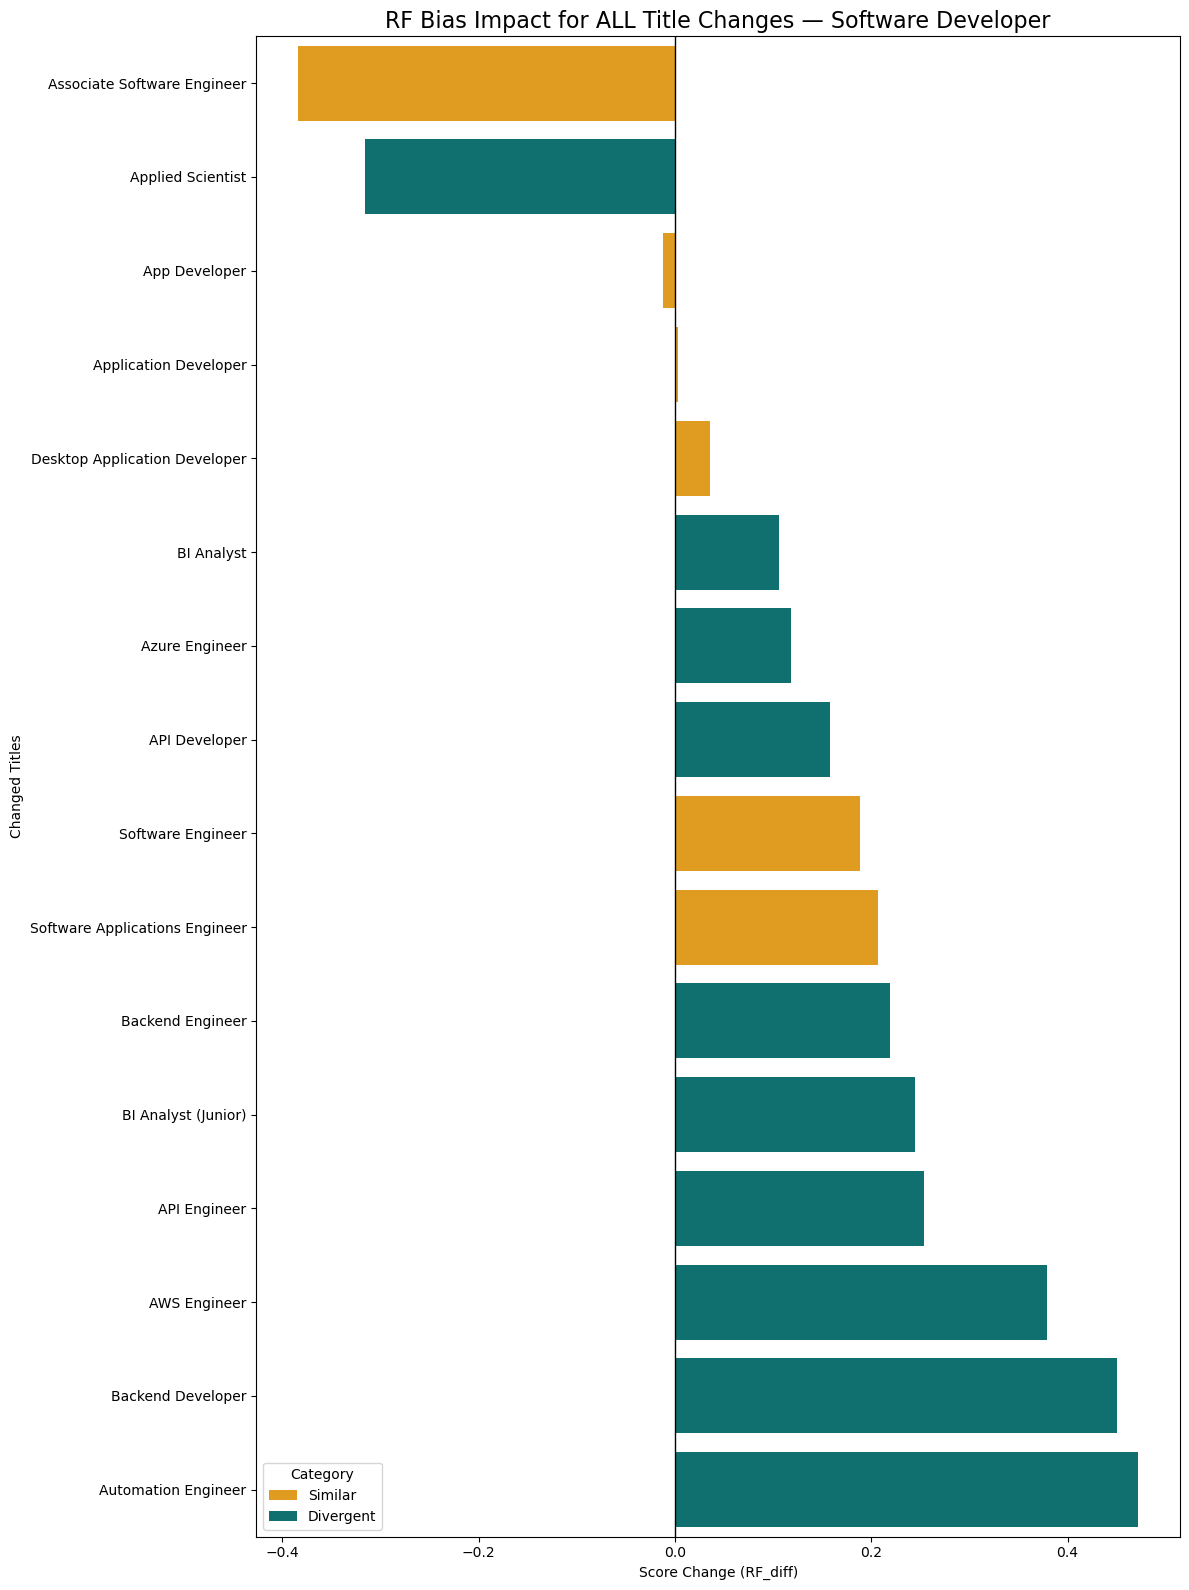

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_bias_all_titles(title):
    df_plot = per_title_change_table(title).copy()

    # Sort by RF_diff so plot looks clean
    df_plot = df_plot.sort_values("RF_diff")

    plt.figure(figsize=(12, 16))   # large figure so all titles are visible
    sns.barplot(
        data=df_plot,
        x="RF_diff",
        y="Changed_title",
        hue="Type",
        palette={"Similar": "orange", "Divergent": "teal"},
        dodge=False
    )

    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"RF Bias Impact for ALL Title Changes — {title}", fontsize=16)
    plt.xlabel("Score Change (RF_diff)")
    plt.ylabel("Changed Titles")
    plt.legend(title="Category")
    plt.tight_layout()
    plt.show()

# Example usage:
plot_bias_all_titles("Software Developer")

### Statistical Testing and Visualizing Title-Bias Effects

In this step, we formally test whether title changes lead to statistically significant score shifts.  
Using one-sample t-tests, we check whether the mean score differences (`RF_diff` and `LR_diff`) for **Similar** and **Divergent** title changes are significantly different from zero for both models.

We also:
- Summarize average score changes per original title and type.
- Use a boxplot to compare the distribution of Random Forest score differences across Similar vs Divergent changes.
- Plot overlapping histograms to visualize how the score change distributions differ between Similar and Divergent title substitutions.

Together, these analyses provide both statistical and visual evidence of job title bias.


In [131]:
from scipy.stats import ttest_1samp

# Similar titles (RF)
sim_rf = cf_df[cf_df["Type"]=="Similar"]["RF_diff"]
t_sim_rf, p_sim_rf = ttest_1samp(sim_rf, 0)

# Divergent titles (RF)
div_rf = cf_df[cf_df["Type"]=="Divergent"]["RF_diff"]
t_div_rf, p_div_rf = ttest_1samp(div_rf, 0)

print("RF Similar Bias: t =", t_sim_rf, "p =", p_sim_rf)
print("RF Divergent Bias: t =", t_div_rf, "p =", p_div_rf)

RF Similar Bias: t = -4.482780426675486 p = 7.414332120493849e-06
RF Divergent Bias: t = -15.432349188634598 p = 2.09232186389426e-53


In [132]:
sim_lr = cf_df[cf_df["Type"]=="Similar"]["LR_diff"]
div_lr = cf_df[cf_df["Type"]=="Divergent"]["LR_diff"]

t_sim_lr, p_sim_lr = ttest_1samp(sim_lr, 0)
t_div_lr, p_div_lr = ttest_1samp(div_lr, 0)

print("LR Similar Bias: t =", t_sim_lr, "p =", p_sim_lr)
print("LR Divergent Bias: t =", t_div_lr, "p =", p_div_lr)

LR Similar Bias: t = -0.4714127019533324 p = 0.6373519097327711
LR Divergent Bias: t = -14.763373298661543 p = 4.719252699054489e-49


In [133]:
title_summary = cf_df.groupby(["Original_title", "Type"]).agg(
    avg_RF_diff = ("RF_diff", "mean"),
    avg_LR_diff = ("LR_diff", "mean"),
    count=("RF_diff","count")
).reset_index()

title_summary.head()

,Original_title,Type,avg_RF_diff,avg_LR_diff,count
0,API Developer,Divergent,-0.025306,0.929479,370
1,API Developer,Similar,0.022505,1.554404,481
2,API Engineer,Divergent,-0.224444,-1.237161,210
3,API Engineer,Similar,-0.183716,-0.778902,273
4,AWS Engineer,Divergent,-0.347978,-0.947466,150


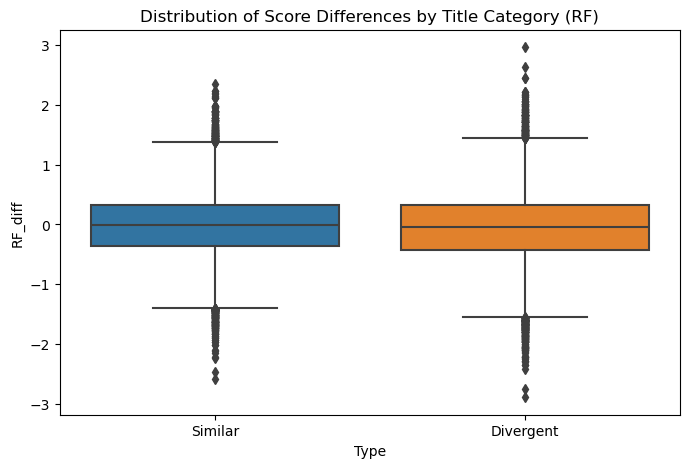

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=cf_df, x="Type", y="RF_diff")
plt.title("Distribution of Score Differences by Title Category (RF)")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


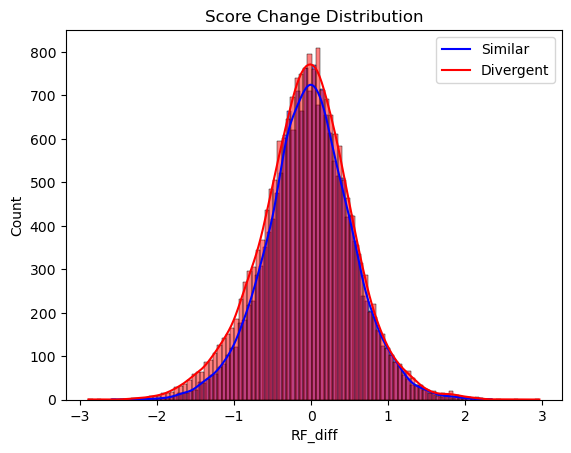

In [135]:
sns.histplot(sim_rf, kde=True, color="blue")
sns.histplot(div_rf, kde=True, color="red")
plt.legend(["Similar", "Divergent"])
plt.title("Score Change Distribution")
plt.show()
